In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
data = pd.read_csv('bank_marketing_clean.csv')
# convert the values and sort from march to december
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(by='date') # Store the sorted values 
# get the columns
cpi = data['cons_price_idx']
euribor = data['euribor_three_months']
date = data['date']

In [2]:
# compute for the quartile
date_Q1 = date.quantile(0.25)
date_Q2 = date.quantile(0.50)
date_Q3 = date.quantile(0.75)
date_Q4 = date.quantile(1)

# Table the Quartiles
date_df = pd.DataFrame({
    "Quarter": ["Quarter 1", "Quarter 2", "Quarter 3", "Quarter 4"],
    'date': [date_Q1, date_Q2, date_Q3, date_Q4]               
     })
#Show the Quartiles
date_df

,Quarter,date
0,Quarter 1,2022-05-16
1,Quarter 2,2022-06-18
2,Quarter 3,2022-08-07
3,Quarter 4,2022-12-31


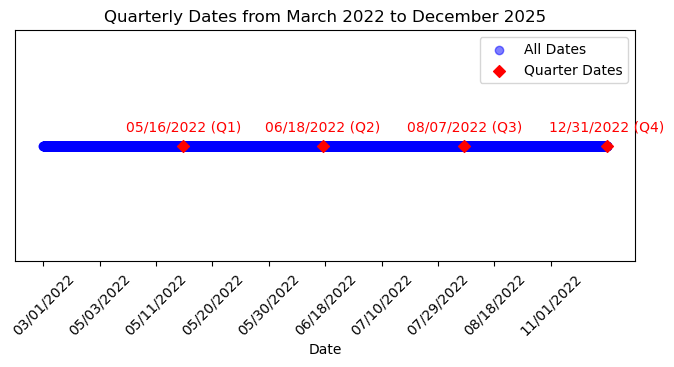

In [3]:
# configure the dates
dates_graph = data['date'].dt.strftime('%m/%d/%Y')  
quarter_dates = [date_Q1, date_Q2, date_Q3, date_Q4]
quarter_labels = ["Q1", "Q2", "Q3", "Q4"]

# get indices for all dates and quarters
date_indices = np.arange(len(dates_graph))
quarter_indices = [dates_graph.tolist().index(q.strftime('%m/%d/%Y')) for q in quarter_dates]

# scatter plot for all dates
plt.figure(figsize=(8, 3)) 
plt.scatter(date_indices, np.zeros_like(date_indices), color="blue", alpha=0.5, label="All Dates")

# highlight the quarters
plt.scatter(quarter_indices, np.zeros_like(quarter_indices), color="red", marker='D', label="Quarter Dates")
for i, q_index in enumerate(quarter_indices):
    plt.annotate(f"{quarter_dates[i].strftime('%m/%d/%Y')} ({quarter_labels[i]})", 
                 (q_index, 0), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='red')

# confiigure the graph
plt.title("Quarterly Dates from March 2022 to December 2025")
plt.xlabel("Date")
plt.xticks(date_indices[::len(date_indices)//10], dates_graph[::len(date_indices)//10], rotation=45)  
plt.yticks([]) 
plt.legend()

# Show the graph
plt.show()


In [4]:
# compute for the quartile
cpi_Q1 = cpi.quantile(0.25)
cpi_Q2 = cpi.quantile(0.50)
cpi_Q3 = cpi.quantile(0.75)
cpi_Q4 = cpi.quantile(1)
# Table the Quartiles
cpi_df = pd.DataFrame({
    "Percentile": ["Quarter 1", "Quarter 2", "Quarter 3", "Quarter 4"],
    "Consumer Price Index Value": [cpi_Q1, cpi_Q2, cpi_Q3, cpi_Q4],
    'Date': [date_Q1, date_Q2, date_Q3, date_Q4] 
})
#Show the Quartiles
cpi_df


,Percentile,Consumer Price Index Value,Date
0,Quarter 1,93.075,2022-05-16
1,Quarter 2,93.749,2022-06-18
2,Quarter 3,93.994,2022-08-07
3,Quarter 4,94.767,2022-12-31


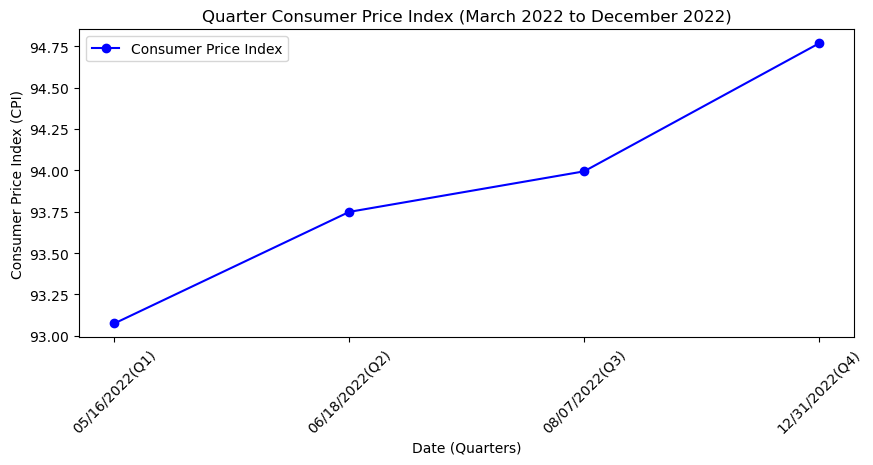

In [5]:
# Store the values into the array
cpi_array =  np.array([cpi_Q1,cpi_Q2,cpi_Q3,cpi_Q4])
date_arrays = np.array([date_Q1.strftime('%m/%d/%Y') + "(Q1)",
                        date_Q2.strftime('%m/%d/%Y')+ "(Q2)"
                        ,date_Q3.strftime('%m/%d/%Y') + "(Q3)"
                        ,date_Q4.strftime('%m/%d/%Y') + "(Q4)"])
# Configure the data size of the plot
plt.figure(figsize=(10, 4))
# get the data and set the labels and colors in the line chart
plt.plot(date_arrays, cpi_array, label="Consumer Price Index", color="blue", marker='o')

# Configure the plot 
plt.title("Quarter Consumer Price Index (March 2022 to December 2022)")
plt.xlabel("Date (Quarters)")
plt.ylabel("Consumer Price Index (CPI)")
plt.xticks(rotation=45)  
plt.legend()

#show the line chart
plt.show()


In [6]:
# compute quartiles for Euribor
euribor_Q1 = euribor.quantile(0.25)
euribor_Q2 = euribor.quantile(0.50)
euribor_Q3 = euribor.quantile(0.75)
euribor_Q4 = euribor.quantile(1)
# Table the Quartiles
euribor_df = pd.DataFrame({
    "Percentile": ["Quarter 1", "Quarter 2", "Quarter 3", "Quarter 4"],
    "Euribor Value": [euribor_Q1, euribor_Q2, euribor_Q3, euribor_Q4],
    'Date': [date_Q1, date_Q2, date_Q3, date_Q4] 
})
#Show the Quartiles
euribor_df


,Percentile,Euribor Value,Date
0,Quarter 1,1.344,2022-05-16
1,Quarter 2,4.857,2022-06-18
2,Quarter 3,4.961,2022-08-07
3,Quarter 4,5.045,2022-12-31


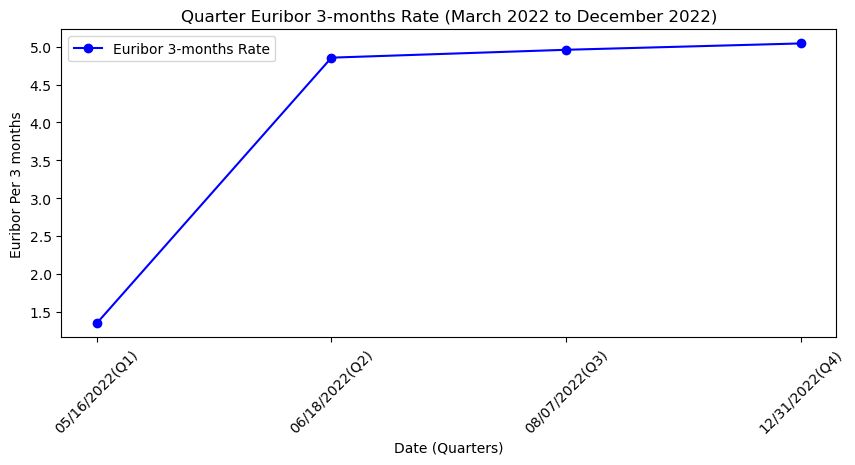

In [7]:
# Store the values into the array
eur_array =  np.array([euribor_Q1,euribor_Q2,euribor_Q3,euribor_Q4])
# Configure the data size of the plot
plt.figure(figsize=(10, 4))
# get the data and set the labels and colors in the line chart
plt.plot(date_arrays, eur_array, label="Euribor 3-months Rate", color="blue", marker='o')

# Configure the plot 
plt.title("Quarter Euribor 3-months Rate (March 2022 to December 2022)")
plt.xlabel("Date (Quarters)")
plt.ylabel("Euribor Per 3 months")
plt.xticks(rotation=45)  
plt.legend()

#show the line chart
plt.show()


In [8]:
# Get the interquartile range
cpi_IQR = cpi_Q3 - cpi_Q1
euribor_IQR = euribor_Q3 - euribor_Q1
# Table the IQR
iqr_df = pd.DataFrame({
    "Metric": ["CPI IQR", "Euribor IQR"],
    "Interquartile Range (IQR)": [cpi_IQR, euribor_IQR],
})
# Show IQR
iqr_df

,Metric,Interquartile Range (IQR)
0,CPI IQR,0.919
1,Euribor IQR,3.617


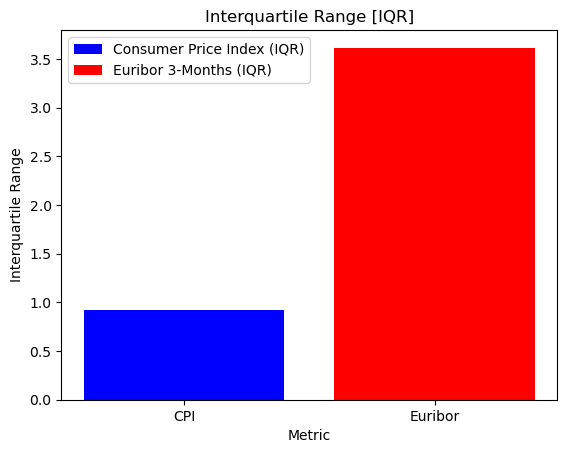

In [9]:
# Configure the bar graph
plt.bar('CPI', cpi_IQR, label='Consumer Price Index (IQR)', color="blue")
plt.bar('Euribor', euribor_IQR, label='Euribor 3-Months (IQR)', color="red")
plt.xlabel("Metric")
plt.ylabel("Interquartile Range")
plt.title("Interquartile Range [IQR]")
plt.legend()

# Show the bar graph
plt.show()